## IMPORTS & CONFIGURATION

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from gensim.models import FastText
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sentence_transformers import SentenceTransformer

# Importer d'autres modules standard si besoin
import os
import sys

In [2]:
from IPython.display import display

In [3]:
#Importation de donnees
df_mono_clean = pd.read_csv("../../data/processed/mono-langue_clean.csv")

## 2. SÉPARER X (TEXTE) ET y (SENTIMENT)

In [4]:
# → Pour df_mono (exemple)
X_mono = df_mono_clean['text_clean_classique'].fillna('').astype(str)
y_mono = df_mono_clean['sentiment'].fillna('neutral')  # Valeur par défaut si NaN

df_affichage = pd.DataFrame({
    'text_clean_classique': X_mono,
    'sentiment': y_mono
})


display(df_affichage.head(5))

df_resume = pd.DataFrame({
    'Indicateur': [
        'Shape de X_mono', 
        'Valeurs uniques de y_mono', 
        'Effectifs par classe (top 3)'
    ],
    'Valeur': [
        str(X_mono.shape),
        str(y_mono.unique().tolist()),
        str(y_mono.value_counts().head(3).to_dict())
    ]
})
display(df_resume)

,text_clean_classique,sentiment
0,great value money,positive
1,love definitely buy,positive
2,work perfectly arrived quickly,positive
3,decent quality price,neutral
4,terrible product broke one use,negative


,Indicateur,Valeur
0,Shape de X_mono,"(500,)"
1,Valeurs uniques de y_mono,"['positive', 'neutral', 'negative']"
2,Effectifs par classe (top 3),"{'negative': 175, 'neutral': 171, 'positive': ..."


## 3. MÉTHODES CLASSIQUES DE VECTORIZATION

In [5]:
print("Vectorisation Bag of Words")

bow_vectorizer = CountVectorizer(
    max_features=5000,      # Limiter de vocabulaire
    min_df=2,               # Ignorer les mots très rares
    max_df=0.8              # Ignorer les mots trop fréquents
)

X_bow = bow_vectorizer.fit_transform(X_mono)

# Stats
vocab_bow = len(bow_vectorizer.vocabulary_)
sparsity_bow = 1 - (X_bow.nnz / (X_bow.shape[0] * X_bow.shape[1]))

print(f"BoW terminé :")
print(f"   • Taille vocabulaire : {vocab_bow}")
print(f"   • Shape matrice : {X_bow.shape}")
print(f"   • Sparsity (creux) : {sparsity_bow*100:.2f}%")

Vectorisation Bag of Words
BoW terminé :
   • Taille vocabulaire : 41
   • Shape matrice : (500, 41)
   • Sparsity (creux) : 92.01%


In [6]:


print("\nVectorisation TF-IDF")

# Recharger les données si le kernel a redémarré
if 'X_mono' not in globals():
    df_mono_clean = pd.read_csv("../data/processed/mono-langue_clean.csv")
    X_mono = df_mono_clean['text_clean_classique'].fillna('').astype(str)

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.8,
    sublinear_tf=True,      # Appliquer log(1+tf) pour réduire l'impact des fréquences élevées
    ngram_range=(1, 2)      # Unigrams + bigrams pour capturer "not good", "very bad"...
)

X_tfidf = tfidf_vectorizer.fit_transform(X_mono)

# Stats
vocab_tfidf = len(tfidf_vectorizer.vocabulary_)
sparsity_tfidf = 1 - (X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1]))

print(f"TF-IDF terminé :")
print(f"   • Taille vocabulaire : {vocab_tfidf}")
print(f"   • Shape matrice : {X_tfidf.shape}")
print(f"   • Sparsity (creux) : {sparsity_tfidf*100:.2f}%")


Vectorisation TF-IDF
TF-IDF terminé :
   • Taille vocabulaire : 75
   • Shape matrice : (500, 75)
   • Sparsity (creux) : 92.60%



COMPARAISON BOOW vs TF-IDF :
| Méthode      |   Vocabulaire |   Dimensions |   Sparsity (%) | Type                    |
|:-------------|--------------:|-------------:|---------------:|:------------------------|
| Bag of Words |            41 |           41 |        92.0146 | Fréquence brute         |
| TF-IDF       |            75 |           75 |        92.6027 | Pondération statistique |


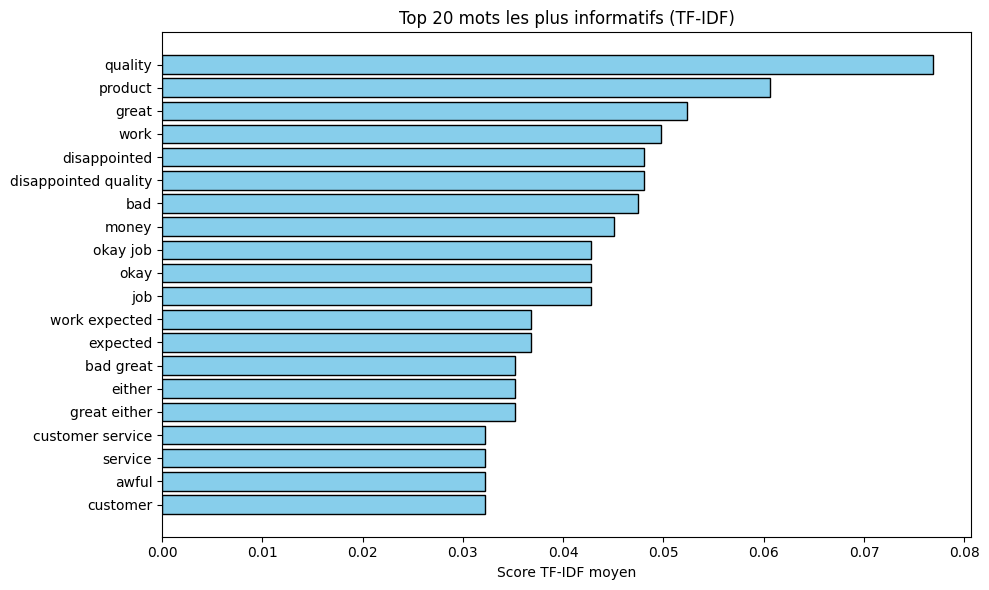

In [7]:
# Comparaison BoW vs TF-IDF
comparison_df = pd.DataFrame({
    'Méthode': ['Bag of Words', 'TF-IDF'],
    'Vocabulaire': [vocab_bow, vocab_tfidf],
    'Dimensions': [X_bow.shape[1], X_tfidf.shape[1]],
    'Sparsity (%)': [sparsity_bow*100, sparsity_tfidf*100],
    'Type': ['Fréquence brute', 'Pondération statistique']
})

print("\nCOMPARAISON BOOW vs TF-IDF :")
print(comparison_df.to_markdown(index=False))

# Visualisation : Top mots TF-IDF
def plot_top_features(vectorizer, X, n=20, title=None):
    feature_names = np.array(vectorizer.get_feature_names_out())
    # Moyenne des scores TF-IDF pour chaque mot
    mean_tfidf = np.asarray(X.mean(axis=0)).flatten()
    top_idx = mean_tfidf.argsort()[-n:][::-1]
    
    if title is None:
        title = f"Top {n} mots les plus informatifs (TF-IDF)"
    
    plt.figure(figsize=(10, 6))
    plt.barh(feature_names[top_idx][::-1], mean_tfidf[top_idx][::-1], color='skyblue', edgecolor='black')
    plt.xlabel('Score TF-IDF moyen')
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_top_features(tfidf_vectorizer, X_tfidf, n=20)

## 5. EMBEDDINGS (REPRÉSENTATION SÉMANTIQUE)

In [8]:
# → Pour df_mono (exemple)
X_mono_light = df_mono_clean['text_clean_light'].fillna('').astype(str)
y_mono_light = df_mono_clean['sentiment'].fillna('neutral')  # Valeur par défaut si NaN

print(f"X_mono shape : {X_mono.shape}")
print(f"y_mono uniques : {y_mono.unique()}")

X_mono shape : (500,)
y_mono uniques : <StringArray>
['positive', 'neutral', 'negative']
Length: 3, dtype: str


### A. Word Embeddings (FastText)

In [9]:
print("Entraînement FastText (Word Embeddings)...")

# Préparer les tokens pour gensim
texts_tokenized = [text.split() for text in X_mono_light if text.strip()]

# Entraîner FastText (rapide et gère les mots rares via subwords)
ft_model = FastText(
    sentences=texts_tokenized,
    vector_size=100,        # Dimension des vecteurs
    window=5,
    min_count=2,
    workers=4,
    epochs=10
)

print(f"FastText entraîné : {len(ft_model.wv)} mots dans le vocabulaire")

# Exemple : vecteur du mot "good"
if 'good' in ft_model.wv:
    print(f"\n🔍 Vecteur de 'good' (10 premières valeurs) : {ft_model.wv['good'][:10]}")
    
    # Mots similaires
    similar = ft_model.wv.most_similar('good', topn=5)
    print(f"🔍 Mots similaires à 'good' : {similar}")

Entraînement FastText (Word Embeddings)...
FastText entraîné : 61 mots dans le vocabulaire

🔍 Vecteur de 'good' (10 premières valeurs) : [-0.0019195  -0.00408147  0.00052484  0.00037453 -0.00089663 -0.00084349
  0.00028587  0.00203491 -0.00059014  0.00114869]
🔍 Mots similaires à 'good' : [('job', 0.0662432610988617), ('does', 0.02371291071176529), ('bad', 0.02077007107436657), ('decent', 0.020722929388284683), ('love', 0.016368350014090538)]


### B. Sentence Embeddings (Sentence-BERT)

In [10]:
print("\nGénération de Sentence Embeddings (SBERT)")

from pathlib import Path

# Charger les embeddings déjà sauvegardés si possible pour éviter un recalcul réseau
sbert_path = Path("../outputs/results/mono_sbert.npy")
if sbert_path.exists():
    X_sbert = np.load(sbert_path)
    print(" SBERT chargé depuis ../outputs/results/mono_sbert.npy")
else:
    # Fallback si le fichier n'existe pas encore
    sentence_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
    batch_size = 32
    X_sbert = sentence_model.encode(
        X_mono.tolist(),
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True
    )
    print(" SBERT calculé puis chargé en mémoire")

print(f"   • Shape : {X_sbert.shape}")
print(f"   • Dimension par embedding : {X_sbert.shape[1]}")
print(f"   • Type : dense (pas de sparsity)")


Génération de Sentence Embeddings (SBERT)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

 SBERT calculé puis chargé en mémoire
   • Shape : (500, 384)
   • Dimension par embedding : 384
   • Type : dense (pas de sparsity)


## 6. COMPARAISON DES MÉTHODES

In [11]:
# Tableau récapitulatif
comparison_table = pd.DataFrame({
    'Méthode': ['Bag of Words', 'TF-IDF', 'FastText (Word)', 'Sentence-BERT'],
    'Type': ['Symbolique', 'Statistique', 'Sémantique (mot)', 'Sémantique (phrase)'],
    'Dimensions': [f'{X_bow.shape[1]}', f'{X_tfidf.shape[1]}', '100 (par mot)', f'{X_sbert.shape[1]}'],
    'Sparsity': [f'{sparsity_bow*100:.1f}%', f'{sparsity_tfidf*100:.1f}%', 'Dense', 'Dense'],
    'Avantage': ['Simple, rapide', 'Pondère mots importants', 'Capture similarités mots', 'Capture contexte phrase'],
    'Inconvénient': ['Pas de sémantique', 'Pas de contexte', 'Nécessite agrégation', 'Lourd en calcul']
})

print("\n" + "="*80)
print("📊 COMPARAISON FINALE DES MÉTHODES DE VECTORIZATION")
print("="*80)
print(comparison_table.to_markdown(index=False))


📊 COMPARAISON FINALE DES MÉTHODES DE VECTORIZATION
| Méthode         | Type                | Dimensions    | Sparsity   | Avantage                 | Inconvénient         |
|:----------------|:--------------------|:--------------|:-----------|:-------------------------|:---------------------|
| Bag of Words    | Symbolique          | 41            | 92.0%      | Simple, rapide           | Pas de sémantique    |
| TF-IDF          | Statistique         | 75            | 92.6%      | Pondère mots importants  | Pas de contexte      |
| FastText (Word) | Sémantique (mot)    | 100 (par mot) | Dense      | Capture similarités mots | Nécessite agrégation |
| Sentence-BERT   | Sémantique (phrase) | 384           | Dense      | Capture contexte phrase  | Lourd en calcul      |


##  VISUALISATION DES EMBEDDINGS

🔄 Réduction de dimension PCA pour visualisation...


C:\Users\user\AppData\Local\Temp\ipykernel_29492\1802712755.py:23: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\user\Desktop\S2_IID2\TM\Tps\env311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


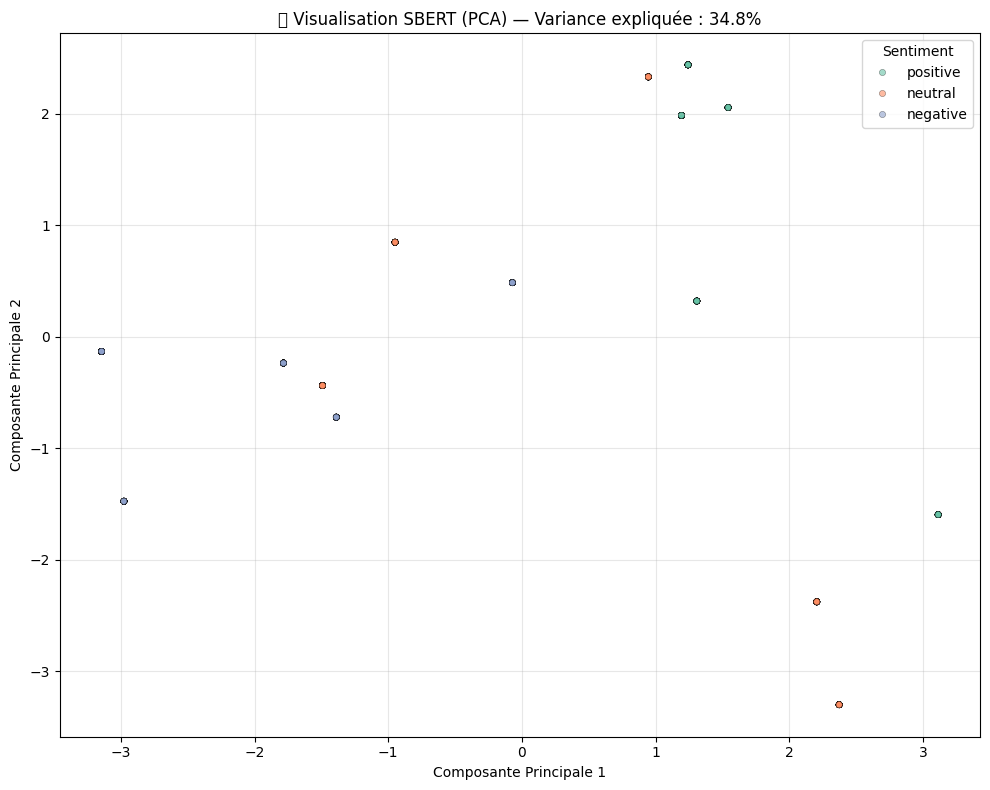

In [12]:
# 🎨 Réduire la dimension avec PCA pour visualiser en 2D
print("🔄 Réduction de dimension PCA pour visualisation...")

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sbert)

# Ajouter les labels sentiment pour colorier
df_viz = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'sentiment': y_mono
})

# Visualisation
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_viz, x='PC1', y='PC2', hue='sentiment', 
                palette='Set2', alpha=0.6, s=20, edgecolor='black', linewidth=0.3)
plt.title(f"🗺️ Visualisation SBERT (PCA) — Variance expliquée : {pca.explained_variance_ratio_.sum()*100:.1f}%")
plt.xlabel('Composante Principale 1')
plt.ylabel('Composante Principale 2')
plt.legend(title='Sentiment')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
sbert_path = Path("../outputs/results/mono_sbert.npy")
# Recharger les données nécessaires si le kernel a redémarré
if 'y_mono' not in globals() or 'df_mono_clean' not in globals():
    df_mono_clean = pd.read_csv("../data/processed/mono-langue_clean.csv")
    y_mono = df_mono_clean['sentiment'].fillna('neutral')

if 'X_sbert' not in globals():
    if sbert_path.exists():
        X_sbert = np.load(sbert_path)
    else:
        from sentence_transformers import SentenceTransformer
        if 'X_mono' not in globals():
            X_mono = df_mono_clean['text_clean_classique'].fillna('').astype(str)
        sentence_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
        X_sbert = sentence_model.encode(
            X_mono.tolist(),
            batch_size=32,
            show_progress_bar=True,
            convert_to_numpy=True
        )

# PCA 3D → plus de variance capturée (~50-60% souvent)
pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_sbert)
variance_3d = pca_3d.explained_variance_ratio_.sum() * 100

df_viz_3d = pd.DataFrame({
    'PC1': X_pca_3d[:, 0],
    'PC2': X_pca_3d[:, 1],
    'PC3': X_pca_3d[:, 2],
    'sentiment': y_mono
})

fig = px.scatter_3d(
    df_viz_3d,
    x='PC1',
    y='PC2',
    z='PC3',
    color='sentiment',
    title=f"SBERT — PCA 3D (Variance expliquée : {variance_3d:.1f}%)",
    labels={'PC1': 'PC1', 'PC2': 'PC2', 'PC3': 'PC3'},
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig.update_traces(marker=dict(size=3, opacity=0.6))
fig.show()

Visualisation avec t-SNE (pas de métrique de variance, mais meilleure séparation visuelle)


C:\Users\user\AppData\Local\Temp\ipykernel_29492\955632283.py:23: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\user\Desktop\S2_IID2\TM\Tps\env311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


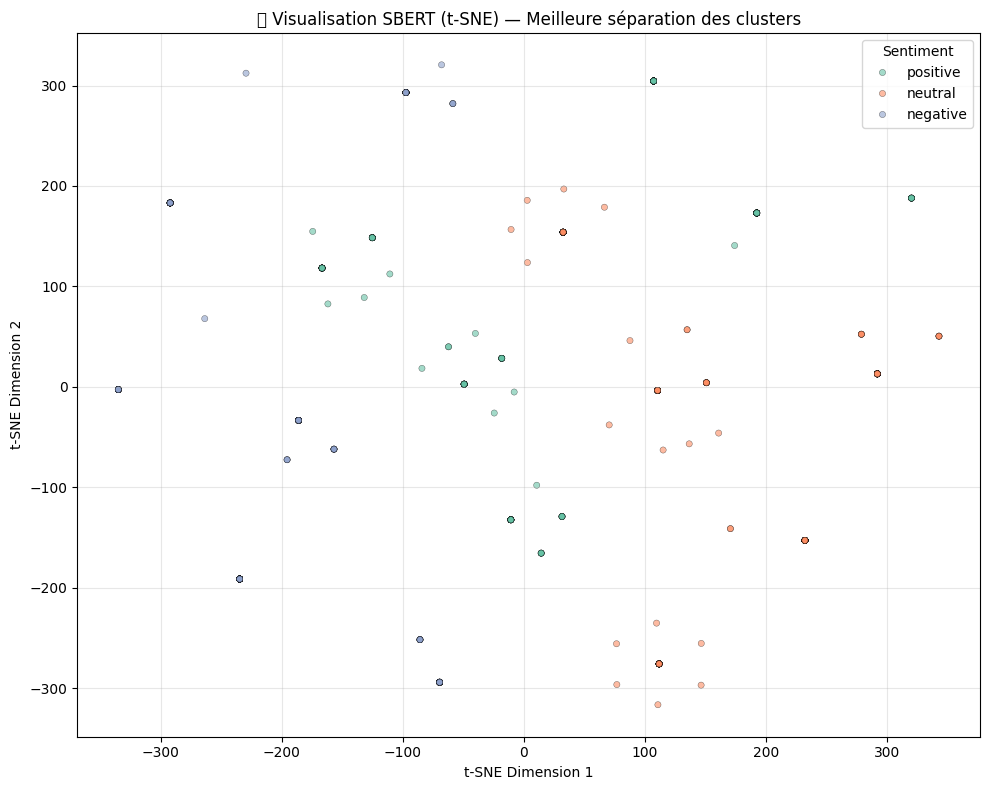

In [14]:
from sklearn.manifold import TSNE

print("Visualisation avec t-SNE (pas de métrique de variance, mais meilleure séparation visuelle)")

# t-SNE est plus lent → utiliser un échantillon si besoin
sample_size = min(2000, len(X_sbert))
X_sample = X_sbert[:sample_size]
y_sample = y_mono.iloc[:sample_size]

tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_sample)

df_viz = pd.DataFrame({'t-SNE 1': X_tsne[:, 0], 't-SNE 2': X_tsne[:, 1], 'sentiment': y_sample})

plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_viz, x='t-SNE 1', y='t-SNE 2', hue='sentiment', 
                palette='Set2', alpha=0.6, s=20, edgecolor='black', linewidth=0.3)
plt.title("🗺️ Visualisation SBERT (t-SNE) — Meilleure séparation des clusters")
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend(title='Sentiment')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. SAUVEGARDER LES VECTEURS

In [16]:
import pickle
from scipy.sparse import save_npz
from pathlib import Path

print(" Sauvegarde des vecteurs pour classification...")

# Créer le répertoire s'il n'existe pas
output_dir = Path("../../outputs/results")
output_dir.mkdir(parents=True, exist_ok=True)

# → TF-IDF (sparse)
save_npz(output_dir / "mono_tfidf.npz", X_tfidf)
with open(output_dir / "tfidf_vectorizer.pkl", 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)

# → SBERT (dense)
np.save(output_dir / "mono_sbert.npy", X_sbert)

# → Metadata (pour reconstruction)
metadata = {
    'shape': X_sbert.shape,
    'sentiment_labels': y_mono.unique().tolist(),
    'model_name': 'paraphrase-multilingual-MiniLM-L12-v2'
}
with open(output_dir / "sbert_metadata.pkl", 'wb') as f:
    pickle.dump(metadata, f)

print(f" Sauvegardes terminées dans {output_dir}")
print("   • mono_tfidf.npz + tfidf_vectorizer.pkl")
print("   • mono_sbert.npy + sbert_metadata.pkl")

 Sauvegarde des vecteurs pour classification...
 Sauvegardes terminées dans ..\..\outputs\results
   • mono_tfidf.npz + tfidf_vectorizer.pkl
   • mono_sbert.npy + sbert_metadata.pkl
